Loading SepFormer 3-speaker model...
Loading input audio...


/DATA1/miniconda3/envs/Speech_Proj/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


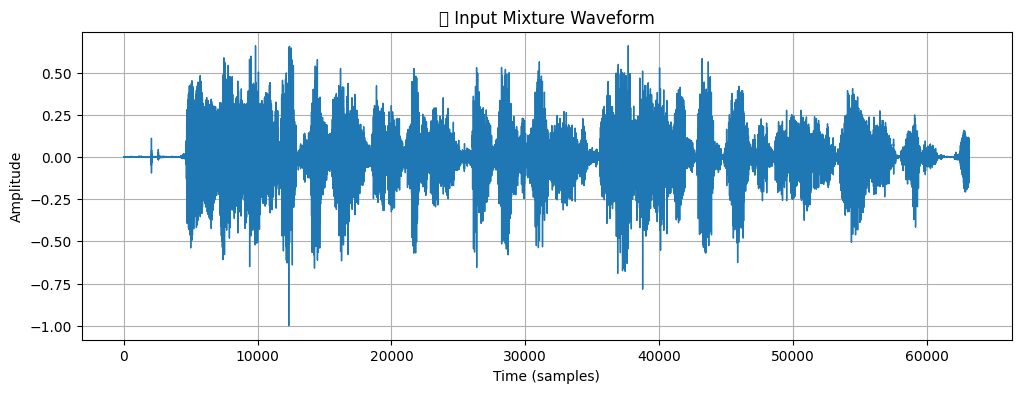

Playing: /home/planck/Ravi_Saxena/Cocktail_Party/Input_Processed/Resampled.wav


Performing 3-speaker speech separation...
Saved: ravi/separated_voice_1.wav


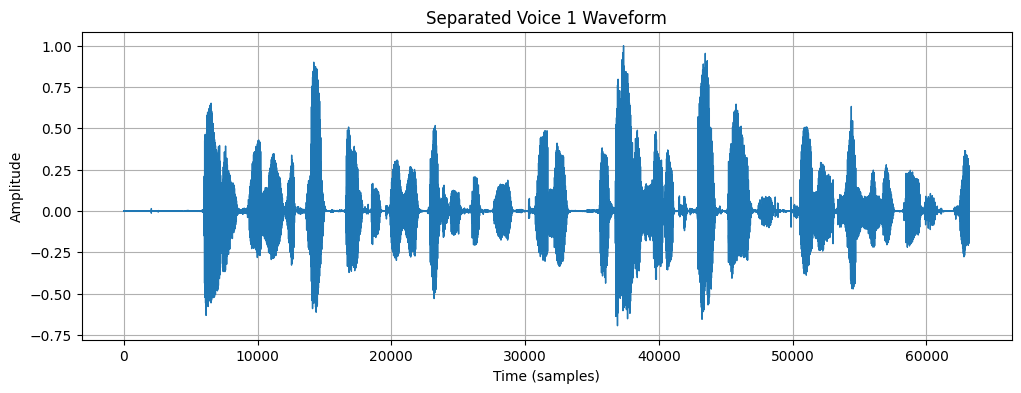

/tmp/ipykernel_1071186/913201658.py:83: FutureWarning: mir_eval.separation.bss_eval_sources
	Deprecated as of mir_eval version 0.8.
	It will be removed in mir_eval version 0.9.
  sdr, _, sar, _ = bss_eval_sources(ref_np[None, :], est_np[None, :])
/DATA1/miniconda3/envs/Speech_Proj/lib/python3.13/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


Metrics for Speaker 1: {'SDR': np.float64(24.76), 'SAR': np.float64(24.76), 'STOI': np.float64(1.0), 'MI': np.float64(11.05), 'SCI': 1.0}
Saved: ravi/separated_voice_2.wav


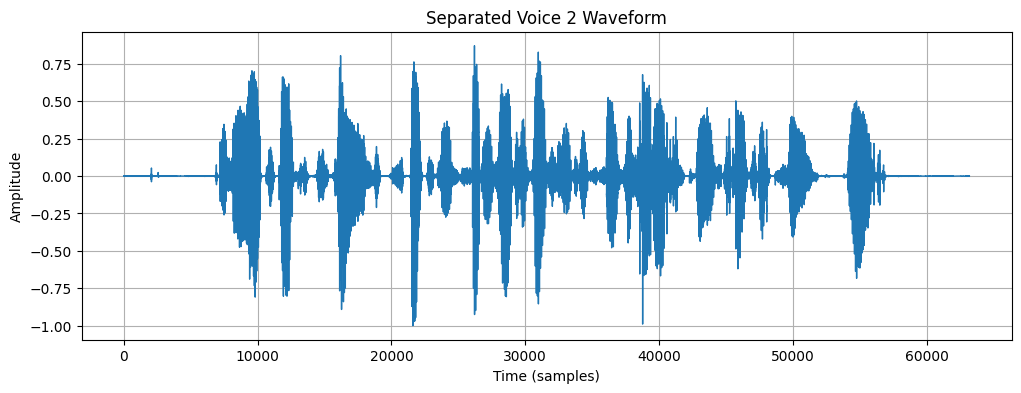

Metrics for Speaker 2: {'SDR': np.float64(24.81), 'SAR': np.float64(24.81), 'STOI': np.float64(1.0), 'MI': np.float64(11.05), 'SCI': 1.0}


/tmp/ipykernel_1071186/913201658.py:83: FutureWarning: mir_eval.separation.bss_eval_sources
	Deprecated as of mir_eval version 0.8.
	It will be removed in mir_eval version 0.9.
  sdr, _, sar, _ = bss_eval_sources(ref_np[None, :], est_np[None, :])
/DATA1/miniconda3/envs/Speech_Proj/lib/python3.13/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


Saved: ravi/separated_voice_3.wav


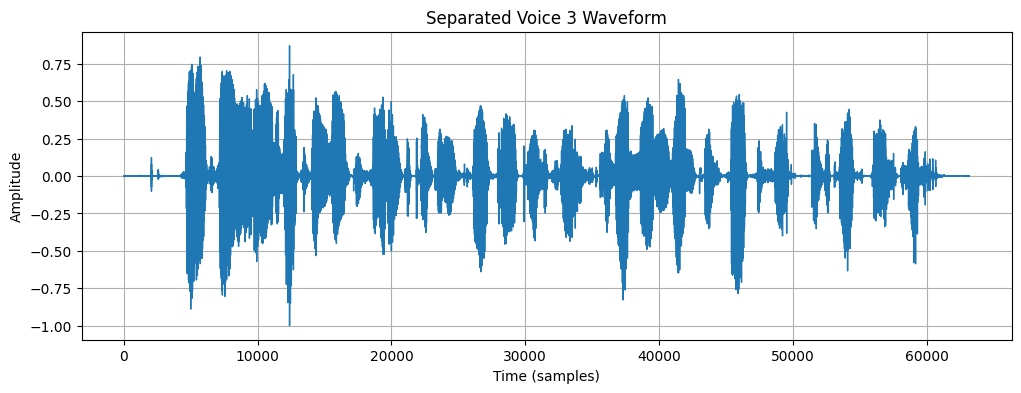

Metrics for Speaker 3: {'SDR': np.float64(24.76), 'SAR': np.float64(24.76), 'STOI': np.float64(1.0), 'MI': np.float64(11.05), 'SCI': 1.0}
Saved combined audio without unlearned voices: ravi/mixed_without_unlearned.wav
Playing: ravi/separated_voice_1.wav


/tmp/ipykernel_1071186/913201658.py:83: FutureWarning: mir_eval.separation.bss_eval_sources
	Deprecated as of mir_eval version 0.8.
	It will be removed in mir_eval version 0.9.
  sdr, _, sar, _ = bss_eval_sources(ref_np[None, :], est_np[None, :])
/DATA1/miniconda3/envs/Speech_Proj/lib/python3.13/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


Playing: ravi/separated_voice_2.wav


Playing: ravi/separated_voice_3.wav


Playing: ravi/mixed_without_unlearned.wav


Saved metrics plot to: metrics_plot.png


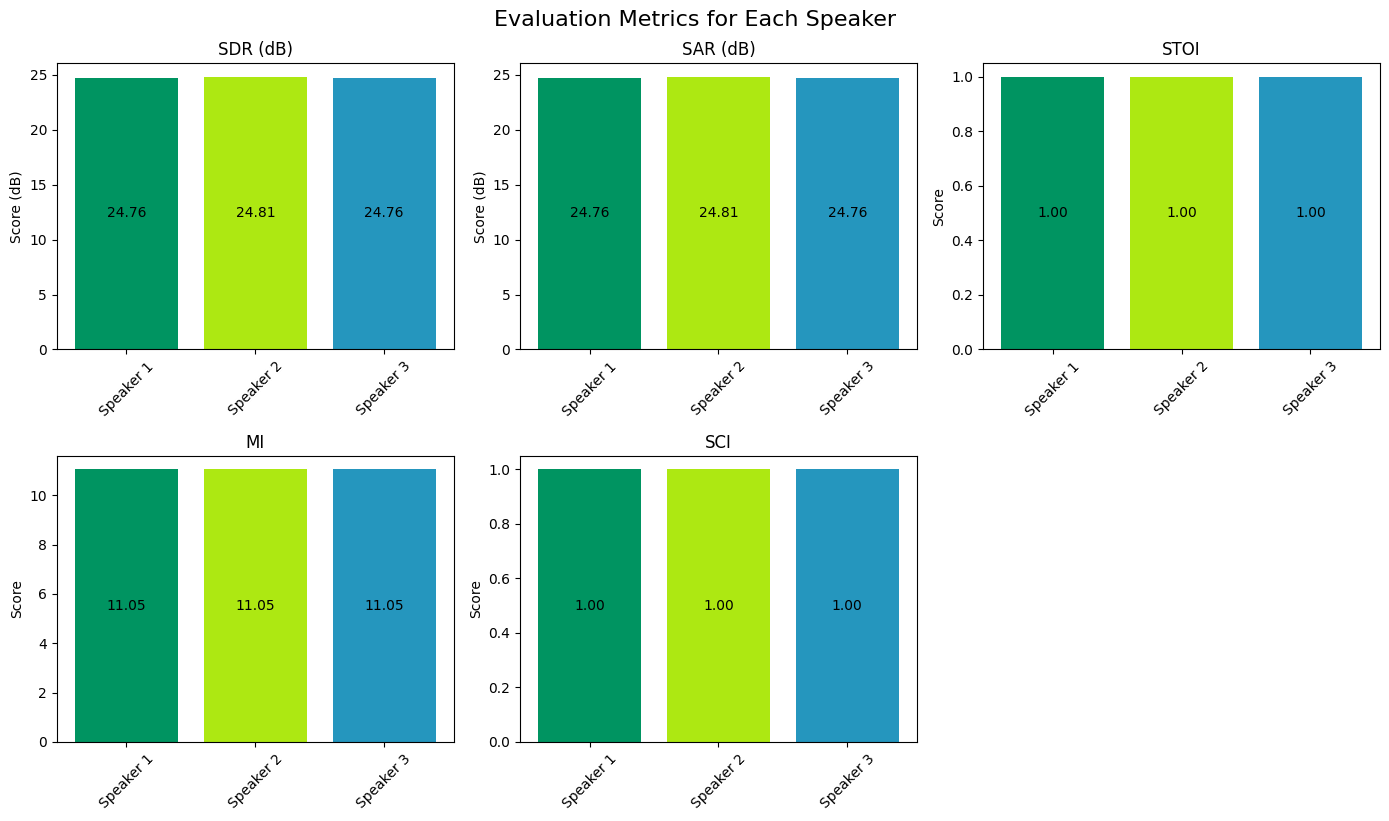

In [4]:
import torchaudio
import torch
import os
import matplotlib.pyplot as plt
from speechbrain.pretrained import SepformerSeparation as separator
from IPython.display import Audio, display
from mir_eval.separation import bss_eval_sources
from pystoi import stoi
import torch.nn.functional as F
from sklearn.metrics import mutual_info_score
import numpy as np

# Visualization

def plot_waveform(waveform, sample_rate, title="Waveform"):
    plt.figure(figsize=(12, 4))
    plt.plot(waveform.numpy(), linewidth=1)
    plt.title(title)
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.show()

def play_audio(audio_path):
    print(f"Playing: {audio_path}")
    display(Audio(audio_path))

# Utility functions

def match_length(original_waveform, separated_waveform):
    orig_length = original_waveform.shape[-1]  
    sep_length = separated_waveform.shape[-1]  
    if sep_length > orig_length:
        return separated_waveform[:, :orig_length]  
    elif sep_length < orig_length:
        pad_amount = orig_length - sep_length
        return torch.nn.functional.pad(separated_waveform, (0, pad_amount))  
    return separated_waveform  

def mutual_information(reference, estimated):
    ref_np = reference.squeeze().numpy()
    est_np = estimated.squeeze().numpy()
    mi = mutual_info_score(ref_np, est_np)
    return mi

def spectral_coherence_index(reference, estimated, sample_rate):
    stft_ref = torch.stft(reference, n_fft=1024, hop_length=512, win_length=1024, return_complex=True)
    stft_est = torch.stft(estimated, n_fft=1024, hop_length=512, win_length=1024, return_complex=True)
    numerator = torch.abs(torch.sum(stft_ref * stft_est.conj(), dim=1))
    norm_ref = torch.sqrt(torch.sum(torch.abs(stft_ref)**2, dim=1))
    norm_est = torch.sqrt(torch.sum(torch.abs(stft_est)**2, dim=1))
    denominator = norm_ref * norm_est
    sci = torch.mean(numerator / (denominator + 1e-8))
    return sci.item()

def recursive_spectral_grouping(waveform, k_ratio=0.75):
    stft_est = torch.stft(waveform, n_fft=1024, hop_length=512, return_complex=True)
    mag = torch.abs(stft_est.squeeze())
    U, S, Vh = torch.linalg.svd(mag, full_matrices=False)
    k = int(k_ratio * len(S))
    S_thresholded = torch.diag(S[:k])
    recon_mag = torch.matmul(U[:, :k], torch.matmul(S_thresholded, Vh[:k, :]))
    return recon_mag, U[:, :k], Vh[:k, :]

def iterative_refinement(original, estimate, max_iter=5, epsilon=1e-3):
    residual = estimate.clone()
    refined = torch.zeros_like(estimate)
    for _ in range(max_iter):
        U, S, Vh = torch.linalg.svd(residual, full_matrices=False)
        rank1 = torch.ger(U[:, 0], Vh[0, :]) * S[0]
        refined += rank1
        residual = residual - rank1
        energy = torch.norm(residual, p='fro')
        if energy < epsilon:
            break
    return refined

def evaluate_metrics(reference, estimated, sample_rate):
    reference = match_length(reference, estimated)
    ref_np = reference.squeeze().numpy()
    est_np = estimated.squeeze().numpy()
    try:
        sdr, _, sar, _ = bss_eval_sources(ref_np[None, :], est_np[None, :])
        sdr_dB = 10 * np.log10(sdr[0])
        sar_dB = 10 * np.log10(sar[0])
    except Exception:
        sdr_dB = sar_dB = float('nan')
    try:
        stoi_score = stoi(ref_np, est_np, sample_rate, extended=False)
    except Exception:
        stoi_score = float('nan')
    mi_score = mutual_information(reference, estimated)
    sci_score = spectral_coherence_index(reference, estimated, sample_rate)
    return {
        "SDR": round(sdr_dB, 2),
        "SAR": round(sar_dB, 2),
        "STOI": round(stoi_score, 2),
        "MI": round(mi_score, 2),
        "SCI": round(sci_score, 2)
    }

def plot_metrics(metrics_dict, save_path="metrics_plot.png"):
    plt.figure(figsize=(14, 8))
    metric_names = ["SDR", "SAR", "STOI", "MI", "SCI"]
    for idx, metric in enumerate(metric_names):
        plt.subplot(2, 3, idx + 1)
        bars = plt.bar(metrics_dict["Speaker"], metrics_dict[metric], color=["#009461","#ade812","#2596be"])
        plt.title(f"{metric} (dB)" if metric in ["SDR", "SAR"] else metric)
        plt.ylabel("Score (dB)" if metric in ["SDR", "SAR"] else "Score")
        plt.xticks(rotation=45)
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height / 2, f'{height:.2f}', ha='center', va='center')
    plt.tight_layout()
    plt.suptitle("Evaluation Metrics for Each Speaker", fontsize=16, y=1.02)

    # Save the figure
    plt.savefig(save_path, bbox_inches='tight')
    print(f"Saved metrics plot to: {save_path}")
    
    plt.show()


def separate_and_unlearn(audio_path, output_dir, unlearn_speakers):
    print("Loading SepFormer 3-speaker model...")
    model = separator.from_hparams(source="speechbrain/sepformer-libri3mix", savedir="pretrained_models/sepformer-librimix-3spk")

    print("Loading input audio...")
    mixture, sample_rate = torchaudio.load(audio_path)
    if mixture.shape[0] > 1:
        mixture = mixture.mean(dim=0, keepdim=True)

    plot_waveform(mixture.squeeze(), sample_rate, title="🎵 Input Mixture Waveform")
    play_audio(audio_path)

    print("Performing 3-speaker speech separation...")
    est_sources = model.separate_file(path=audio_path)  

    if est_sources.ndim != 3:
        raise ValueError(f"Unexpected separated sources shape: {est_sources.shape}.")

    os.makedirs(output_dir, exist_ok=True)
    separated_audio_paths = []
    num_speakers = est_sources.shape[2]
    combined_output = torch.zeros_like(est_sources[0, :, 0])

    metrics_all = {"Speaker": [], "SDR": [], "SAR": [], "STOI": [], "MI": [], "SCI": []}

    for i in range(num_speakers):  
        separated_voice = est_sources[0, :, i].detach().cpu().unsqueeze(0)
        separated_voice = match_length(mixture, separated_voice)

        output_path = os.path.join(output_dir, f"separated_voice_{i+1}.wav")
        torchaudio.save(output_path, separated_voice, sample_rate)
        print(f"Saved: {output_path}")
        separated_audio_paths.append(output_path)

        plot_waveform(separated_voice.squeeze(), sample_rate, title=f"Separated Voice {i+1} Waveform")
        metrics = evaluate_metrics(mixture.squeeze(), separated_voice.squeeze(), sample_rate)
        print(f"Metrics for Speaker {i+1}: {metrics}")

        metrics_all["Speaker"].append(f"Speaker {i+1}")
        for key in metrics:
            metrics_all[key].append(metrics[key])

        if (i + 1) not in unlearn_speakers:
            combined_output += separated_voice.squeeze()

    combined_output = match_length(mixture, combined_output.unsqueeze(0))
    mixed_output_path = os.path.join(output_dir, "mixed_without_unlearned.wav")
    torchaudio.save(mixed_output_path, combined_output, sample_rate)
    print(f"Saved combined audio without unlearned voices: {mixed_output_path}")

    for path in separated_audio_paths:
        play_audio(path)

    play_audio(mixed_output_path)
    plot_metrics(metrics_all)

# Entry Point
if __name__ == "__main__":
    input_audio = ("/home/planck/Ravi_Saxena/Cocktail_Party/Input_Processed/Resampled.wav").strip()
    output_directory = input("Enter the output directory: ").strip()
    unlearn_input = input("Enter speaker numbers to unlearn (comma-separated, e.g., 1,3). Press Enter for none: ").strip()
    unlearn_speakers = list(map(int, unlearn_input.split(','))) if unlearn_input else []
    separate_and_unlearn(input_audio, output_directory, unlearn_speakers)


In [7]:
import os
import numpy as np
import torchaudio
import matplotlib.pyplot as plt
from glob import glob
from collections import defaultdict
from speechbrain.pretrained import SepformerSeparation as separator

def batch_separate_and_evaluate(folder_path, output_dir, unlearn_speakers):
    all_metrics = defaultdict(list)
    flac_files = sorted(glob(os.path.join(folder_path, "*.flac")))

    if not flac_files:
        print("No .flac files found in the folder.")
        return

    for idx, file_path in enumerate(flac_files, 1):
        print(f"\n [{idx}/{len(flac_files)}] Processing: {file_path}")
        sub_output_dir = os.path.join(output_dir, f"output_{idx}")
        os.makedirs(sub_output_dir, exist_ok=True)

        model = separator.from_hparams(source="speechbrain/sepformer-libri3mix",
                                       savedir="pretrained_models/sepformer-librimix-3spk")
        mixture, sample_rate = torchaudio.load(file_path)
        if mixture.shape[0] > 1:
            mixture = mixture.mean(dim=0, keepdim=True)
        est_sources = model.separate_file(path=file_path)

        if est_sources.ndim != 3:
            raise ValueError(f"Unexpected shape for separated sources: {est_sources.shape}")

        num_speakers = est_sources.shape[2]
        for i in range(num_speakers):
            separated = est_sources[0, :, i].detach().cpu().unsqueeze(0)
            separated = match_length(mixture, separated)
            metrics = evaluate_metrics(mixture.squeeze(), separated.squeeze(), sample_rate)

            for key in metrics:
                all_metrics[key].append(metrics[key])

    # Compute average metrics
    avg_metrics = {key: round(np.mean(values), 2) for key, values in all_metrics.items()}
    print("\n Average Metrics Across All Files and Speakers:")
    for key, val in avg_metrics.items():
        print(f"{key}: {val}")

    # Plot and save as PNG
    plt.figure(figsize=(10, 5))
    metric_names = ["SDR", "SAR", "STOI", "MI", "SCI"]
    avg_values = [avg_metrics.get(metric, 0) for metric in metric_names]
    bars = plt.bar(metric_names, avg_values, color=["#009461","#ade812","#2596be"])
    for bar, value in zip(bars, avg_values):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.5,
                 f'{value:.2f}', ha='center', va='top')
    plt.ylabel("Average Score")
    plt.title("Average Metrics Across LibriCSS Dataset")
    plt.grid(True, axis='y')
    plt.tight_layout()

    # Save plot
    plot_path = os.path.join(output_dir, "average_metrics.png")
    plt.savefig(plot_path)
    print(f"\n Metrics plot saved at: {plot_path}")

    plt.show()

if __name__ == "__main__":
    input_folder = input("Enter the folder path containing .flac files: ").strip()
    output_directory = input("Enter the output directory: ").strip()
    unlearn_input = input("Enter speaker numbers to unlearn (comma-separated, e.g., 1,3). Press Enter for none: ").strip()
    unlearn_speakers = list(map(int, unlearn_input.split(','))) if unlearn_input else []
    batch_separate_and_evaluate(input_folder, output_directory, unlearn_speakers)
